# Exploratory Data Analysis (EDA)

## Task 1: NAV Trend Analysis (2022–2026)

### Objective
Analyze the daily Net Asset Value (NAV) movement of all 40 mutual fund schemes from January 2022 to May 2026. The visualization highlights the broad market rally during 2023 and the market correction observed during 2024.

In [2]:
# Task 1 : NAV Trend Analysis


import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path
import sys
# print(sys.executable)

import kaleido

import plotly.io as pio

# print(pio.renderers)

import plotly

# %pip show plotly
# %pip show kaleido

import os

# Create Charts folder if it doesn't exist
os.makedirs("../Reports/Charts", exist_ok=True)

In [3]:
# Load cleaned NAV history dataset
nav_df = pd.read_csv("../Data/Processed/02_nav_history_cleaned.csv")

# Display first five rows
nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
print(nav_df.info())
print(nav_df.columns)
print(nav_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB
None
Index(['amfi_code', 'date', 'nav'], dtype='object')
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [5]:
# Loading Fund Master dataset
fund_df = pd.read_csv("../Data/Processed/01_fund_master_cleaned.csv")

# Checking columns
fund_df.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [6]:
# Merging NAV history with fund master to get scheme details
nav_df = nav_df.merge(
    fund_df[['amfi_code', 'scheme_name', 'fund_house', 'category']],
    on='amfi_code',
    how='left'
)
# Doing Left Join to keep all NAV history records and add scheme details from fund master dataset

# Converting date column to datetime
nav_df['date'] = pd.to_datetime(nav_df['date'])

# Verifying merged dataset
nav_df.head()

,amfi_code,date,nav,scheme_name,fund_house,category
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity


In [7]:
print(f"Total Records : {len(nav_df)}")
print(f"Unique Schemes : {nav_df['scheme_name'].nunique()}")
print(f"Date Range : {nav_df['date'].min().date()} to {nav_df['date'].max().date()}")

nav_df.head()

Total Records : 46000
Unique Schemes : 40
Date Range : 2022-01-03 to 2026-05-29


,amfi_code,date,nav,scheme_name,fund_house,category
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity


In [8]:
fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)"
    },
    template="plotly_white",
    height=750
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-03-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.10,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-07-01",
    x1="2024-10-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)


fig.update_layout(
    title=dict(
        text="Daily NAV Trend of 40 Mutual Fund Schemes (2022–2026)",
        x=0.5
    ),
    xaxis_title="Date",
    yaxis_title="Net Asset Value (NAV)",
    hovermode="x unified",
    legend_title="Scheme",
    font=dict(size=12)
)

fig.update_traces(
    line=dict(width=1.5),
    opacity=0.75
)

fig.show()

In [9]:
import os

# Create Charts folder if it doesn't exist
os.makedirs("../Reports/Charts", exist_ok=True)

# Export Plotly figure
fig.write_image(
    "../Reports/Charts/nav_trend_analysis.png",
    width=1600,
    height=900,
    scale=2
)

print("Chart exported successfully!")

Chart exported successfully!


### Key Insights

1. The majority of mutual fund schemes exhibited a long-term upward NAV trend between 2022 and 2026, indicating sustained capital appreciation over the study period.

2. During the 2023 bull run, most equity-oriented schemes experienced accelerated NAV growth, reflecting favourable market sentiment.

3. A temporary slowdown and correction in NAV movement is visible during mid-2024, corresponding to broader market volatility.

4. Debt and liquid funds displayed comparatively stable NAV movements with lower volatility than equity-oriented schemes.

5. Considerable variation exists in absolute NAV values across schemes due to differences in launch dates, fund strategies, and historical appreciation; therefore, raw NAV values should not be interpreted as a direct measure of fund performance.

# Task 2: AUM Growth Analysis (2022–2025)

**Objective**

Analyze the year-wise Assets Under Management (AUM) growth of mutual fund houses from 2022 to 2025 using a grouped bar chart. Highlight SBI Mutual Fund's market-leading AUM of approximately ₹12.5 lakh crore.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned AUM dataset
aum_df = pd.read_csv("../Data/Processed/03_aum_by_fund_house_cleaned.csv")

# Preview
aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [11]:
aum_df.info()

print(aum_df.columns)

aum_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   fund_house      90 non-null     object 
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3.6+ KB
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [12]:
# Convert date column to datetime
aum_df["date"] = pd.to_datetime(aum_df["date"])

# Extract Year
aum_df["year"] = aum_df["date"].dt.year

# Keep only required years
aum_df = aum_df[aum_df["year"].between(2022, 2025)]

# Verify
aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


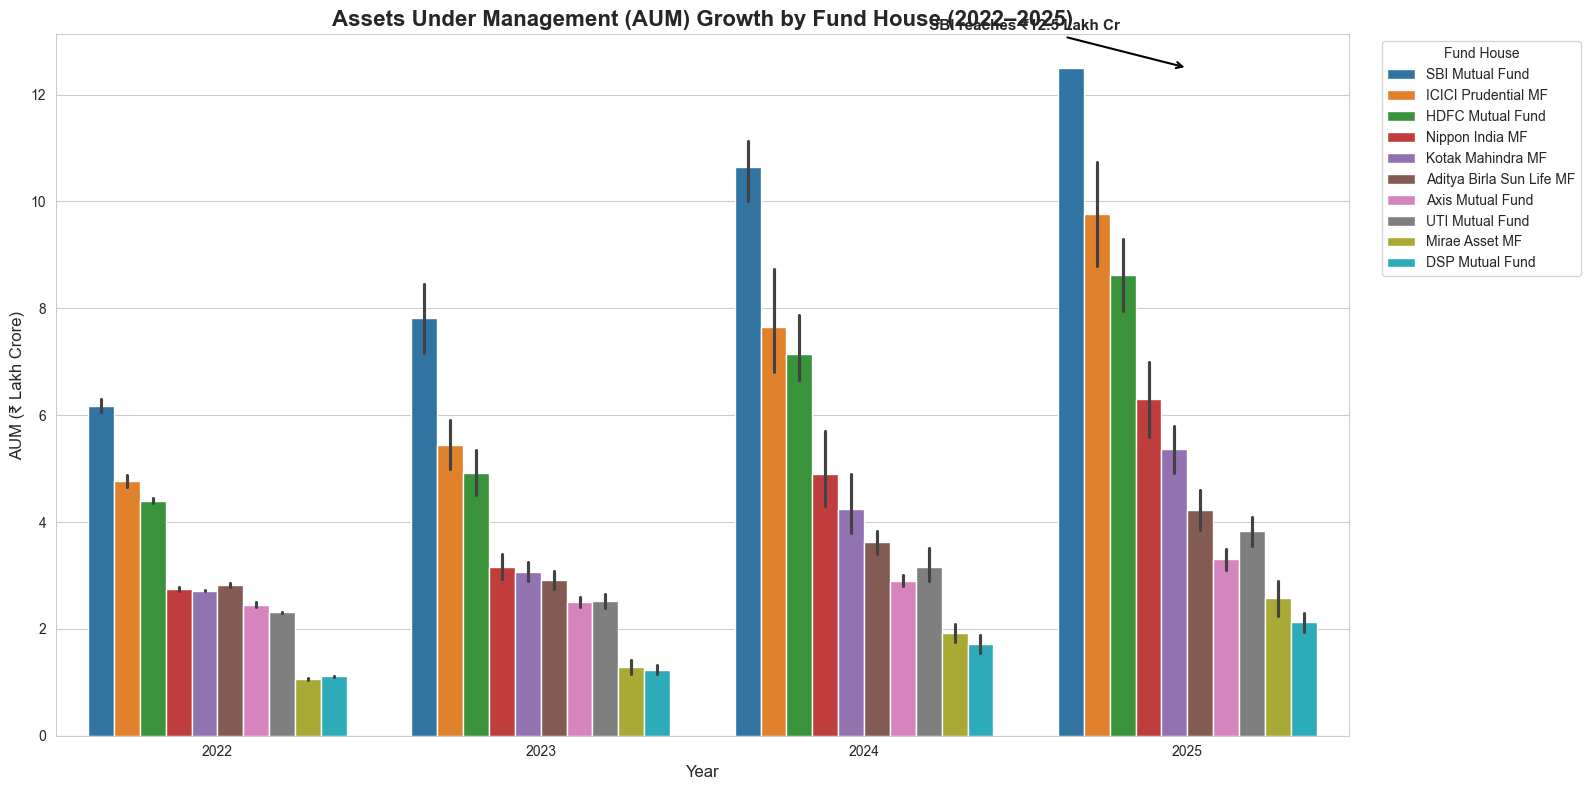

In [13]:
# Set style
sns.set_style("whitegrid")

plt.figure(figsize=(16, 8))

ax = sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

# Titles
plt.title(
    "Assets Under Management (AUM) Growth by Fund House (2022–2025)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("AUM (₹ Lakh Crore)", fontsize=12)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Highlight SBI 2025
plt.annotate(
    "SBI reaches ₹12.5 Lakh Cr",
    xy=(3, 12.5),
    xytext=(2.2, 13.2),
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        color="black",
        lw=1.5
    )
)

plt.tight_layout()
plt.show()

In [14]:
plt.savefig(
    "../Reports/Charts/aum_growth_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

### Key EDA Findings

- Assets Under Management (AUM) increased steadily across almost all fund houses between 2022 and 2025, indicating sustained growth in the mutual fund industry.

- SBI Mutual Fund remained the market leader throughout the period and reached an AUM of ₹12.5 lakh crore by 2025, significantly ahead of its competitors.

- HDFC Mutual Fund and ICICI Prudential Mutual Fund consistently ranked among the top fund houses, demonstrating strong asset growth over the study period.

- Mid-sized fund houses also recorded positive AUM growth, reflecting increasing investor participation and market expansion.

- The grouped bar chart highlights the widening gap between the industry's largest fund houses and smaller asset management companies over time.

## Task 3: SIP Inflow Time-Series (2022–2025)

**Objective**

Analyze the monthly Systematic Investment Plan (SIP) inflows from January 2022 to December 2025 and highlight the record monthly inflow of ₹31,002 crore achieved in December 2025.

In [15]:
# Load Monthly SIP Inflows dataset
sip_df = pd.read_csv("../Data/Processed/04_monthly_sip_inflows_cleaned.csv")

# Convert month column to datetime
sip_df["month"] = pd.to_datetime(sip_df["month"])

print(sip_df.info())

display(sip_df.head())
display(sip_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[ns]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 2.4 KB
None


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
count,48,48.000000,48.000000,48.000000,48.000000,36.000000
mean,2023-12-16 11:00:00,19577.520833,7.189583,9.893750,8.632083,31.456944
min,2022-01-01 00:00:00,11438.000000,4.910000,7.500000,4.800000,15.800000
25%,2022-12-24 06:00:00,13658.500000,6.110000,8.775000,5.790000,20.245000
50%,2023-12-16 12:00:00,18224.000000,7.150000,9.200000,7.265000,28.295000
75%,2024-12-08 18:00:00,25944.250000,8.300000,9.562500,10.525000,40.807500
max,2025-12-01 00:00:00,31002.000000,9.350000,46.000000,15.900000,53.050000
std,NaN,6354.329621,1.271457,5.370745,3.613579,11.768190


In [22]:
import plotly.express as px

fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows in India (January 2022 – December 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    },
    template="plotly_white"
)

# Improve line and marker appearance
fig.update_traces(
    line=dict(color="#1f77b4", width=3),
    marker=dict(size=7)
)

# Annotate all-time high (Dec 2025)
fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High<br>₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    ax=-60,
    ay=-50,
    font=dict(size=12)
)

# Improve layout
fig.update_layout(
    title_x=0.5,
    hovermode="x unified",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    font=dict(size=12),
    height=650
)

fig.show()

In [23]:
fig.write_image(
    "../Reports/Charts/monthly_sip_inflows.png",
    width=1600,
    height=900,
    scale=2
)

### Key EDA Findings

- Monthly SIP inflows exhibited a strong upward trend from January 2022 to December 2025, indicating sustained growth in retail investor participation.

- SIP inflows crossed ₹30,000 crore for the first time in December 2025, reaching an all-time high of ₹31,002 crore.

- Despite short-term market volatility, monthly SIP contributions remained resilient, reflecting investors' long-term investment approach.

- The continuous increase in active SIP accounts and SIP assets under management supports the industry's steady expansion during the study period.

- The overall trend highlights growing investor confidence in mutual funds as a preferred long-term wealth creation instrument.

## Task 4: Category-wise Net Inflow Heatmap

### Objective

Analyze the monthly net inflows across different mutual fund categories using a heatmap. The visualization highlights periods of strong and weak investor interest by representing net inflow values through colour intensity.

In [24]:
# Load Category Inflows dataset
category_df = pd.read_csv("../Data/Processed/05_category_inflows_cleaned.csv")

# Convert month column to datetime
category_df["month"] = pd.to_datetime(category_df["month"])

category_df.head()

,month,category,net_inflow_crore
0,2024-04-01,ELSS,466.0
1,2024-04-01,Flexi Cap,4947.0
2,2024-04-01,Gilt,784.0
3,2024-04-01,Hybrid,2955.0
4,2024-04-01,Large & Mid Cap,4214.0


In [25]:
# Create pivot table for heatmap

heatmap_data = category_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0
Large Cap,2413.0,2076.0,2519.0,2574.0,1940.0,1879.0,2255.0,1870.0,1923.0,2025.0,1925.0,2234.0
Liquid,37537.0,41872.0,40486.0,34643.0,41952.0,35308.0,39091.0,40506.0,34933.0,33892.0,32374.0,38681.0
Mid Cap,3897.0,5300.0,5047.0,4548.0,3899.0,4960.0,4106.0,4336.0,5023.0,4316.0,4819.0,5061.0
Sectoral/Thematic,8052.0,8354.0,10030.0,9896.0,8360.0,8518.0,7680.0,7397.0,9820.0,7893.0,9215.0,8614.0


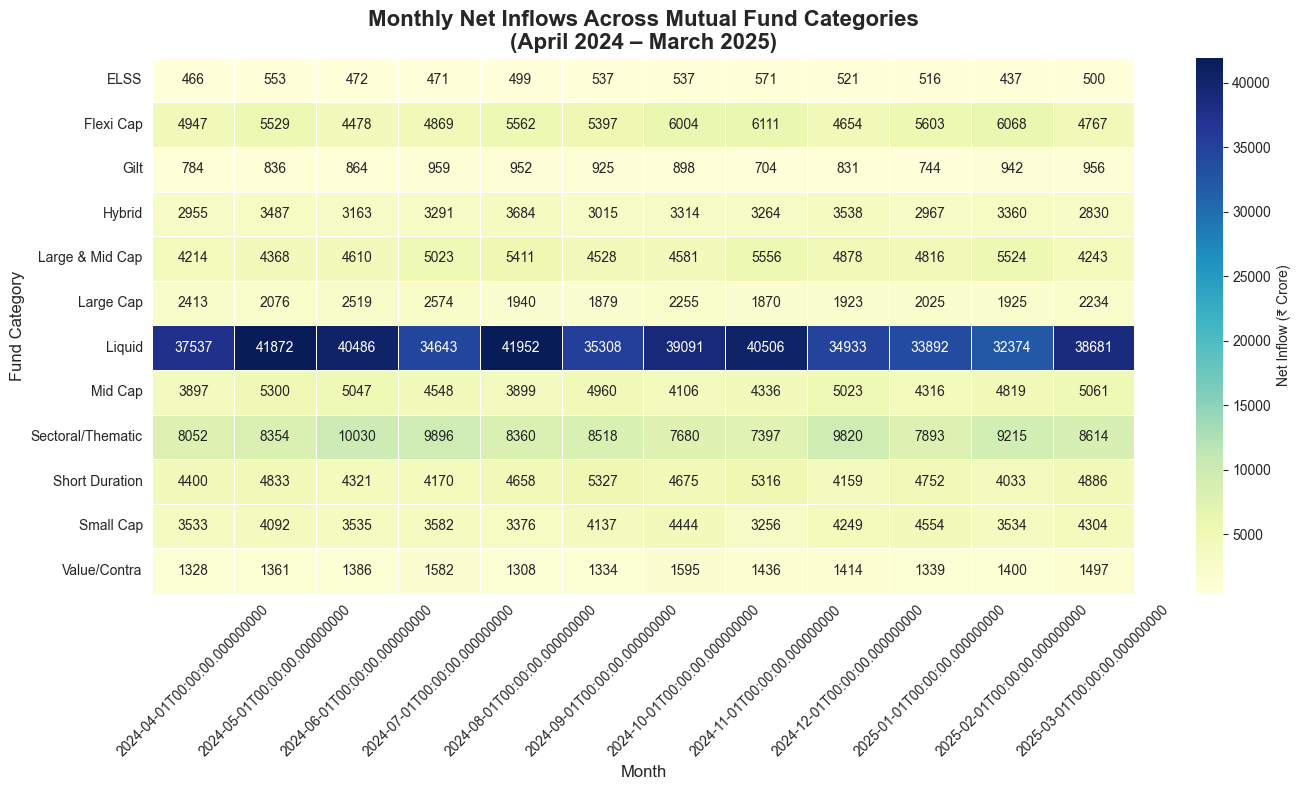

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title(
    "Monthly Net Inflows Across Mutual Fund Categories\n(April 2024 – March 2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Fund Category", fontsize=12)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../Reports/Charts/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### Key EDA Findings

1. Liquid Funds consistently recorded the highest monthly net inflows throughout the analysis period, indicating strong investor preference for low-risk and highly liquid investment options.

2. Sectoral/Thematic Funds and Flexi Cap Funds attracted substantial inflows, reflecting growing investor interest in thematic and diversified equity investments.

3. Large Cap Funds experienced comparatively moderate inflows, suggesting that investors increasingly diversified towards mid-cap, small-cap, and thematic categories.

4. ELSS and Gilt Funds maintained relatively stable inflows across all months, indicating consistent demand for tax-saving and government-backed investment options.

5. The heatmap highlights clear differences in investor allocation patterns across fund categories, providing insights into changing market preferences over time.

## Task 5: Investor Demographics Analysis

### Objective

Analyze investor demographics using transaction data to understand participation across different age groups and genders. Additionally, examine the distribution of SIP investment amounts across age groups.

In [28]:
# Load Investor Transactions dataset

investor_df = pd.read_csv("../Data/Processed/08_investor_transactions_cleaned.csv")

investor_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [29]:
sip_transactions = investor_df[
    investor_df["transaction_type"] == "SIP"
].copy()

print(f"Total SIP Transactions: {len(sip_transactions)}")

Total SIP Transactions: 19716


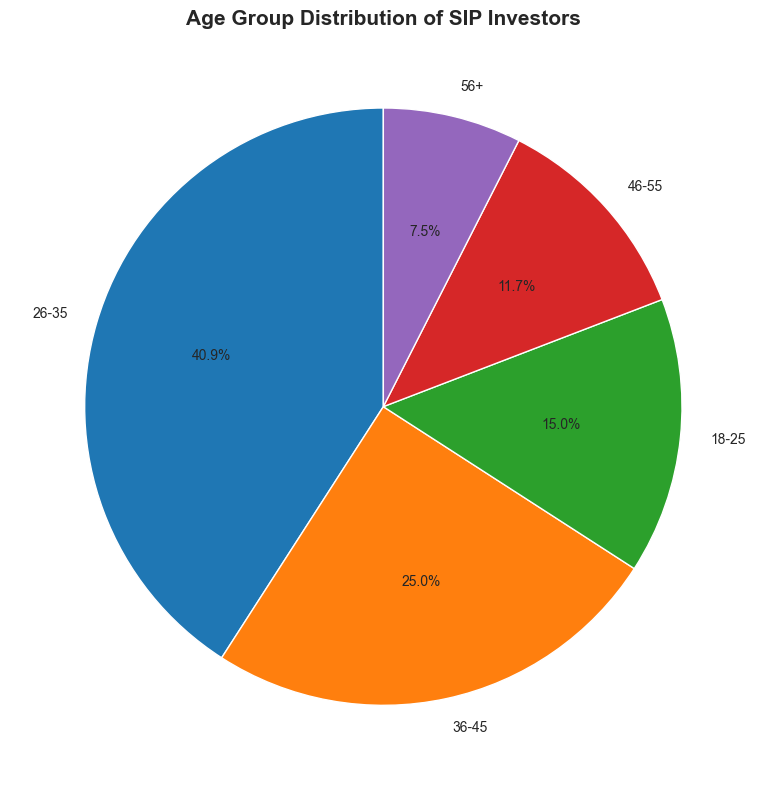

In [30]:
import matplotlib.pyplot as plt

age_counts = sip_transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Age Group Distribution of SIP Investors",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../Reports/Charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

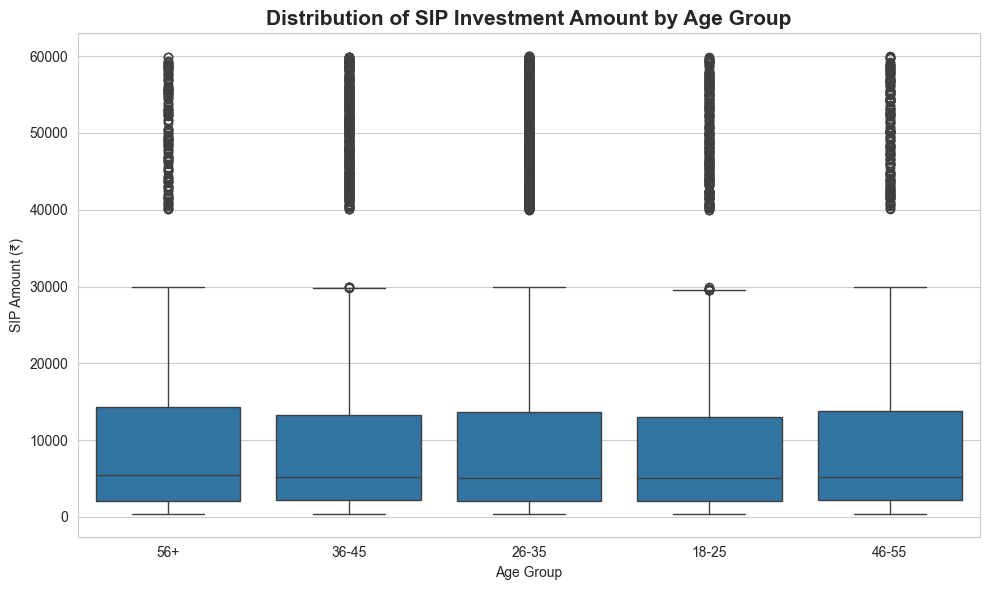

In [31]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "Distribution of SIP Investment Amount by Age Group",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../Reports/Charts/sip_amount_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

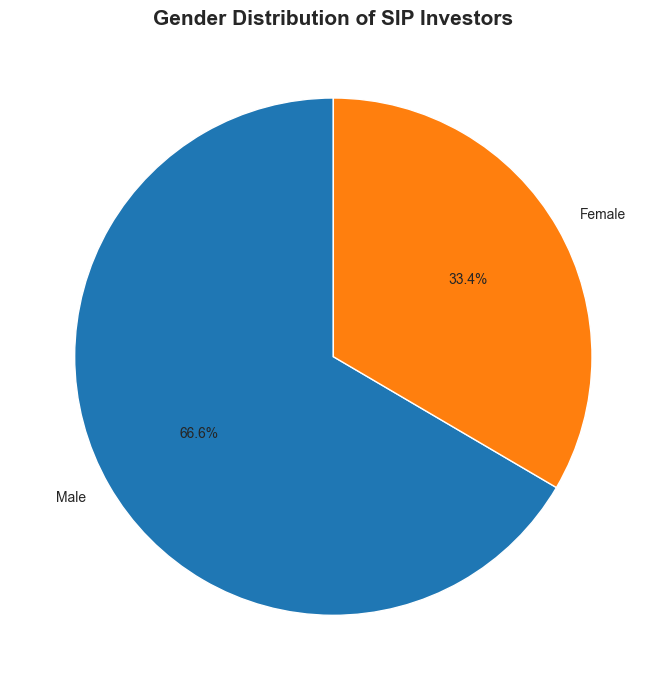

In [32]:
gender_counts = sip_transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Gender Distribution of SIP Investors",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../Reports/Charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key EDA Findings

1. Investors aged **26–35** and **36–45** constitute the largest share of SIP investors, indicating that working professionals are the primary contributors to systematic investments.

2. The SIP amount distribution varies across age groups, with some older investors making larger periodic investments, as reflected by wider box plot distributions.

3. Male and female investor participation is relatively balanced, demonstrating increasing financial inclusion across genders.

4. Younger investors (18–25) contribute a smaller proportion of SIP investments, suggesting significant future growth potential.

5. The demographic analysis highlights that SIPs are widely adopted across all age groups, supporting long-term wealth creation.

## Task 6: Geographic Distribution

### Objective

Analyze the geographical distribution of SIP investments across Indian states and compare investor participation between T30 and B30 city tiers.

In [33]:
geo_df = pd.read_csv("../Data/Processed/08_investor_transactions_cleaned.csv")

sip_geo = geo_df[
    geo_df["transaction_type"]=="SIP"
].copy()

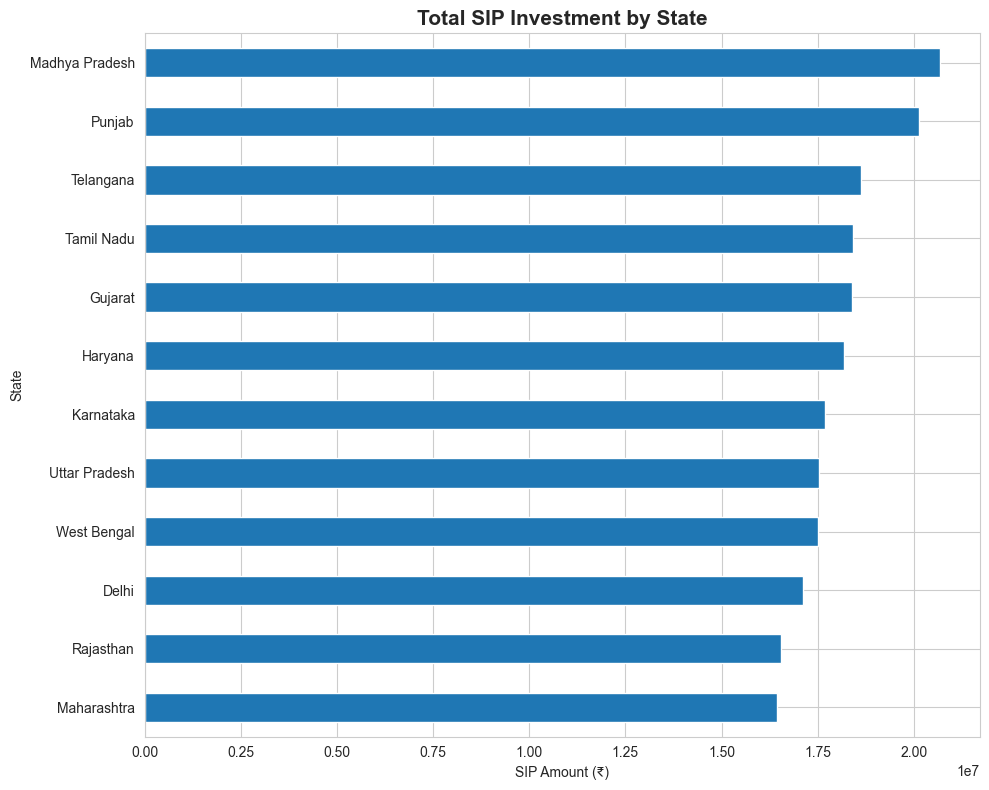

In [34]:
state_data = (
    sip_geo
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,8))

state_data.plot(kind="barh")

plt.title(
    "Total SIP Investment by State",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../Reports/Charts/statewise_sip_amount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

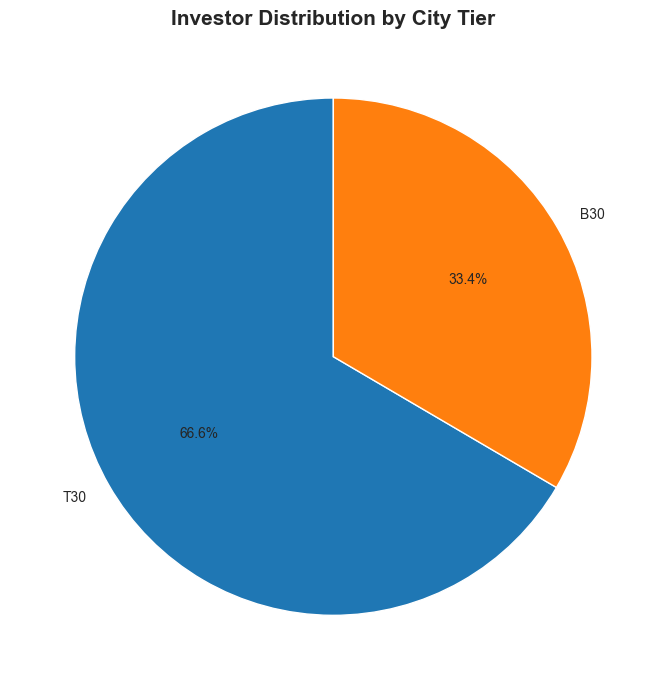

In [35]:
tier = sip_geo["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Distribution by City Tier",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../Reports/Charts/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key EDA Findings

1. SIP investments are concentrated in economically developed states, reflecting stronger financial awareness and higher disposable incomes.

2. T30 cities contribute a larger share of SIP investments, highlighting the dominance of metropolitan regions in mutual fund participation.

3. B30 cities continue to contribute significantly, indicating increasing mutual fund penetration beyond major urban centres.

4. Geographic diversification suggests growing investor awareness across multiple regions of India.

5. Expansion into B30 cities presents a strong opportunity for future growth in the mutual fund industry.

## Task 7: Industry Folio Count Growth

### Objective

Analyze the growth in mutual fund folios between January 2022 and December 2025 and identify major milestones reflecting increasing investor participation.

In [36]:
folio_df = pd.read_csv("../Data/Processed/06_industry_folio_count_cleaned.csv")

folio_df["month"] = pd.to_datetime(folio_df["month"])

folio_df.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [37]:
import plotly.express as px

fig = px.line(
    folio_df,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth in Mutual Fund Folios (2022–2025)",
    labels={
        "month":"Month",
        "total_folios_crore":"Total Folios (Crore)"
    },
    template="plotly_white"
)

# Starting milestone
fig.add_annotation(
    x="2022-01-01",
    y=13.26,
    text="13.26 Cr",
    showarrow=True,
    arrowhead=2
)

# Ending milestone
fig.add_annotation(
    x="2025-12-01",
    y=26.12,
    text="26.12 Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_traces(
    line=dict(width=3),
    marker=dict(size=7)
)

fig.update_layout(
    title_x=0.5,
    hovermode="x unified",
    height=650
)

fig.show()

In [38]:
fig.write_image(
    "../Reports/Charts/folio_growth.png",
    width=1600,
    height=900,
    scale=2
)

### Key EDA Findings

1. Total mutual fund folios increased from **13.26 crore** in January 2022 to **26.12 crore** by December 2025, reflecting substantial industry growth.

2. The steady upward trend indicates sustained participation from retail investors throughout the analysis period.

3. Growth in folios suggests increasing financial awareness and wider adoption of mutual fund investments across India.

4. Equity-oriented schemes continued to drive overall folio expansion, supported by consistent SIP investments.

5. The near doubling of folio count over four years demonstrates the rapid expansion of India's mutual fund ecosystem.

## Task 8: NAV Return Correlation Matrix

### Objective

Analyze the correlation of daily returns among selected mutual fund schemes to understand diversification opportunities and relationships between fund performances.

In [39]:
nav_df = pd.read_csv("../Data/Processed/02_nav_history_cleaned.csv")
fund_df = pd.read_csv("../Data/Processed/01_fund_master_cleaned.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])

In [40]:
nav_df = nav_df.merge(
    fund_df[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

In [41]:
selected_funds = (
    nav_df["scheme_name"]
    .drop_duplicates()
    .sort_values()
    .head(10)
)

selected_funds

3450     ABSL Frontline Equity Fund - Regular - Growth
5750               ABSL Liquid Fund - Regular - Growth
4600            ABSL Small Cap Fund - Regular - Growth
17250             Axis Bluechip Fund - Direct - Growth
16100            Axis Bluechip Fund - Regular - Growth
18400              Axis Midcap Fund - Regular - Growth
19550           Axis Small Cap Fund - Regular - Growth
43700               DSP Midcap Fund - Regular - Growth
44850            DSP Small Cap Fund - Regular - Growth
42550       DSP Top 100 Equity Fund - Regular - Growth
Name: scheme_name, dtype: object

In [42]:
selected_df = nav_df[
    nav_df["scheme_name"].isin(selected_funds)
].copy()

In [43]:
selected_df["daily_return"] = (
    selected_df
    .groupby("scheme_name")["nav"]
    .pct_change()
)

In [44]:
return_matrix = selected_df.pivot_table(
    index="date",
    columns="scheme_name",
    values="daily_return"
)

return_matrix.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth
date,,,,,,,,,,
2022-01-04,0.001153,-0.000141,-0.010865,-0.000187,-0.006561,-0.003597,0.018757,0.000482,-0.010498,-0.008592
2022-01-05,0.003866,0.000382,0.000603,-0.002863,-0.007511,0.016595,0.019898,0.008670,-0.002593,-0.006480
2022-01-06,-0.002128,-0.000143,-0.029101,-0.009811,0.009926,-0.000246,-0.000431,-0.013861,-0.008382,-0.003818
2022-01-07,-0.006314,0.000215,0.024766,0.008215,0.009331,-0.018524,0.032482,0.004317,0.011680,-0.004069
2022-01-10,0.011548,0.000690,0.001251,0.005685,-0.009961,-0.006878,0.026144,0.003650,0.001356,0.001601


In [45]:
correlation = return_matrix.corr()

correlation

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth
scheme_name,,,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1.000000,-0.027230,0.010202,0.012036,0.056952,-0.040309,-0.029799,-0.000607,-0.004785,0.021622
ABSL Liquid Fund - Regular - Growth,-0.027230,1.000000,-0.007530,-0.038607,-0.029781,0.010877,0.039690,0.027775,-0.010105,0.020234
ABSL Small Cap Fund - Regular - Growth,0.010202,-0.007530,1.000000,0.056726,0.013961,0.017462,-0.029528,0.011435,-0.006471,0.020669
Axis Bluechip Fund - Direct - Growth,0.012036,-0.038607,0.056726,1.000000,-0.003216,0.030734,-0.009111,0.016425,0.017761,0.006239
Axis Bluechip Fund - Regular - Growth,0.056952,-0.029781,0.013961,-0.003216,1.000000,0.015815,0.037383,-0.023655,0.013288,0.018544
Axis Midcap Fund - Regular - Growth,-0.040309,0.010877,0.017462,0.030734,0.015815,1.000000,-0.011836,-0.020921,-0.017765,0.036254
Axis Small Cap Fund - Regular - Growth,-0.029799,0.039690,-0.029528,-0.009111,0.037383,-0.011836,1.000000,-0.012415,-0.000828,0.025630
DSP Midcap Fund - Regular - Growth,-0.000607,0.027775,0.011435,0.016425,-0.023655,-0.020921,-0.012415,1.000000,0.007160,-0.029903
DSP Small Cap Fund - Regular - Growth,-0.004785,-0.010105,-0.006471,0.017761,0.013288,-0.017765,-0.000828,0.007160,1.000000,0.003233


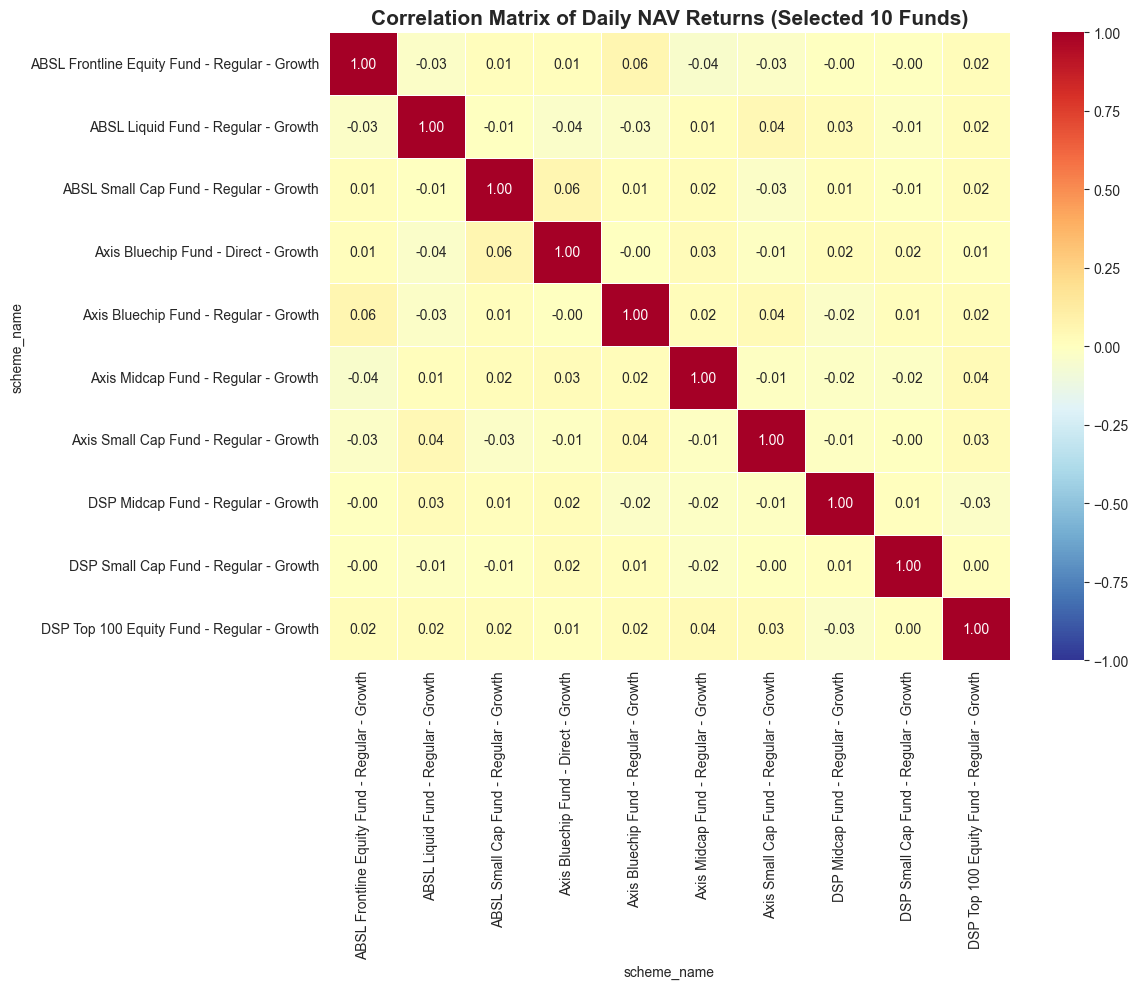

In [46]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="RdYlBu_r",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Daily NAV Returns (Selected 10 Funds)",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../Reports/Charts/nav_return_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key EDA Findings

1. Most selected mutual fund schemes exhibit positive correlations, reflecting their exposure to common market movements.

2. Funds within similar investment categories tend to have stronger correlations due to comparable portfolio compositions.

3. Lower correlation values indicate potential diversification opportunities for investors seeking to reduce portfolio risk.

4. No significant negative correlations were observed, suggesting that most schemes generally move in the same market direction.

5. The correlation matrix provides valuable insights for portfolio construction by identifying funds with varying return relationships.

## Task 9: Sector Allocation Analysis

### Objective

Analyze the sector-wise allocation of mutual fund portfolios by aggregating portfolio weights across all equity funds. The visualization highlights the sectors receiving the highest investment allocation.

In [47]:
portfolio_df = pd.read_csv("../Data/Processed/09_portfolio_holdings_cleaned.csv")

portfolio_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,100016,WIPRO,Wipro Ltd,IT,25.90,552.43,579.31,2025-12-31
1,100016,MARUTI,Maruti Suzuki India Ltd,Automobile,14.84,486.21,5808.83,2025-12-31
2,100016,HINDUNILVR,Hindustan Unilever Ltd,FMCG,11.68,1590.03,2555.06,2025-12-31
3,100016,SUNPHARMA,Sun Pharmaceutical Industries,Pharma,11.53,398.60,2074.55,2025-12-31
4,100016,DRREDDY,Dr. Reddy's Laboratories,Pharma,9.03,452.67,2212.60,2025-12-31


In [48]:
sector_df = (
    portfolio_df
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sector_df.head()

,sector,weight_pct
0,Banking,652.26
1,IT,455.47
2,Pharma,407.45
3,Automobile,323.65
4,Utilities,265.54


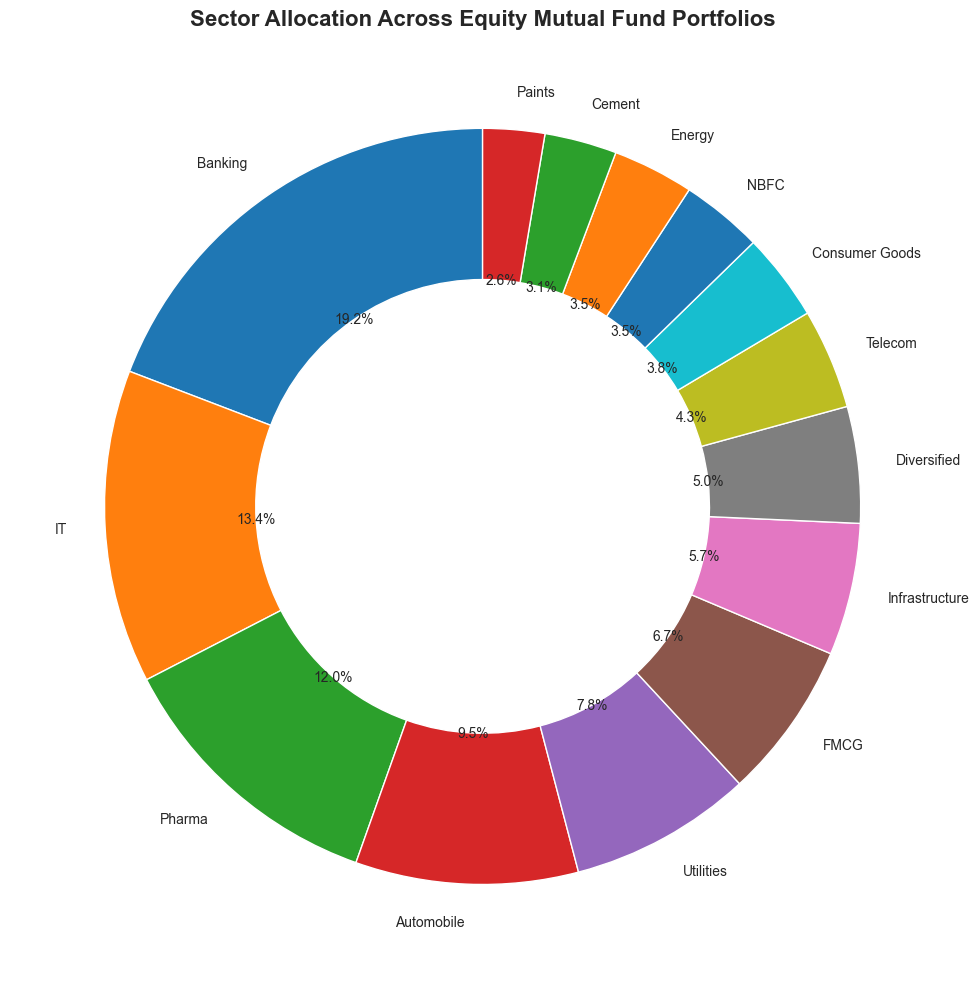

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

plt.pie(
    sector_df["weight_pct"],
    labels=sector_df["sector"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.40)
)

plt.title(
    "Sector Allocation Across Equity Mutual Fund Portfolios",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../Reports/Charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key EDA Findings

1. Banking and Financial Services constitute one of the largest sector allocations, reflecting their dominant role in equity mutual fund portfolios.

2. Diversified exposure across sectors such as Information Technology, Pharmaceuticals, Utilities, and Consumer Goods helps reduce concentration risk.

3. Sector allocation indicates that fund managers maintain diversified portfolios while allocating higher weights to fundamentally strong industries.

4. Defensive sectors such as Pharmaceuticals and Utilities provide portfolio stability during periods of market volatility.

5. The sector allocation pattern demonstrates a balanced investment strategy across cyclical and defensive sectors.

## Task 10: Top 10 Fund Houses by Assets Under Management

### Objective

Identify the leading Asset Management Companies (AMCs) based on their Assets Under Management (AUM) to understand market concentration and industry leadership.

C:\Users\hitin\AppData\Local\Temp\ipykernel_9080\1556533765.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


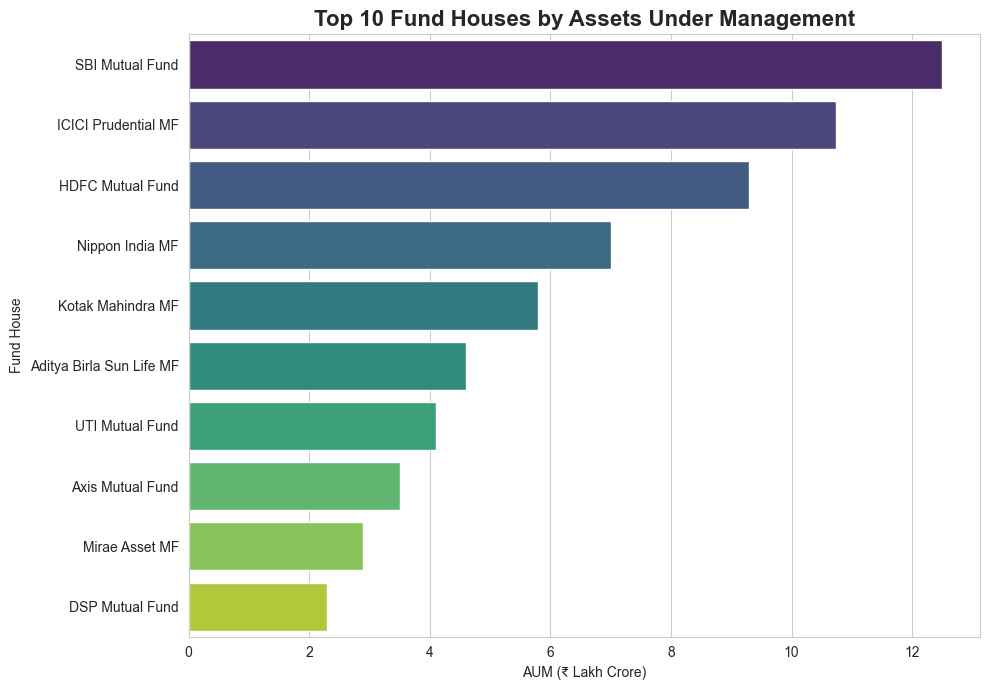

In [50]:
aum_df = pd.read_csv("../Data/Processed/03_aum_by_fund_house_cleaned.csv")

aum_df["date"] = pd.to_datetime(aum_df["date"])

latest_aum = (
    aum_df
    .sort_values("date")
    .groupby("fund_house")
    .tail(1)
    .sort_values("aum_lakh_crore", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,7))

sns.barplot(
    data=latest_aum,
    y="fund_house",
    x="aum_lakh_crore",
    palette="viridis"
)

plt.title(
    "Top 10 Fund Houses by Assets Under Management",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("AUM (₹ Lakh Crore)")
plt.ylabel("Fund House")

plt.tight_layout()

plt.savefig(
    "../Reports/Charts/top10_fundhouses_aum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key EDA Findings

1. SBI Mutual Fund holds the highest Assets Under Management among all AMCs.
2. HDFC Mutual Fund and ICICI Prudential Mutual Fund remain major market participants.
3. The chart highlights significant concentration among India's largest asset management companies.

## Task 11: Top 10 Portfolio Holdings

### Objective

Identify the most heavily weighted stocks across all equity mutual fund portfolios.

C:\Users\hitin\AppData\Local\Temp\ipykernel_9080\2753014859.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


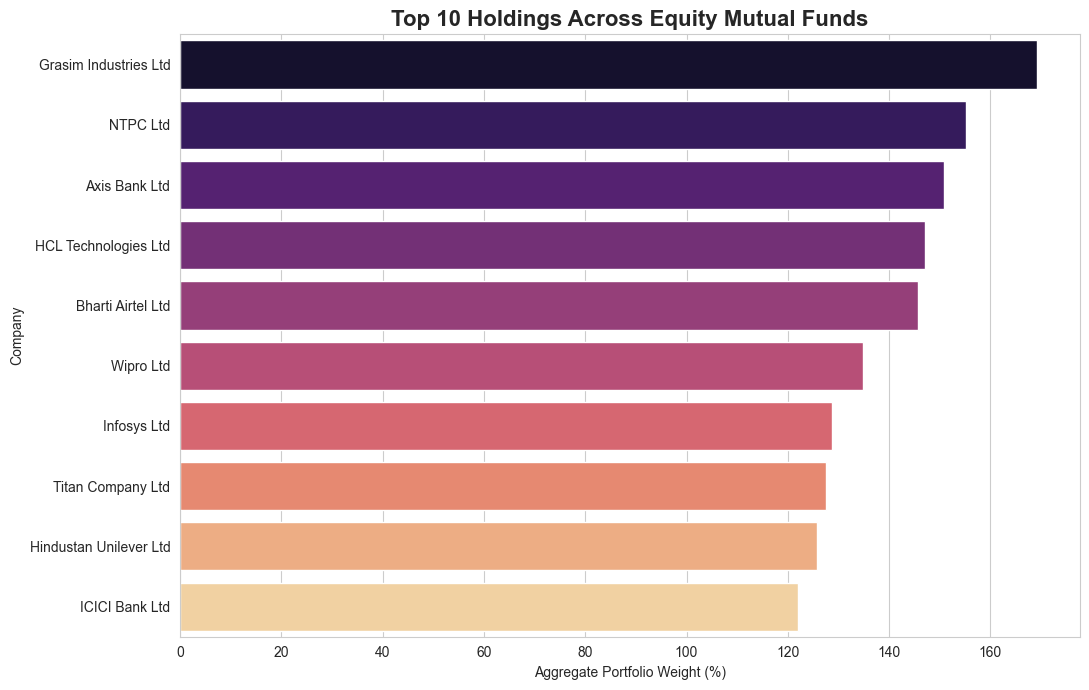

In [51]:
portfolio_df = pd.read_csv("../Data/Processed/09_portfolio_holdings_cleaned.csv")

top_holdings = (
    portfolio_df
    .groupby("stock_name")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(11,7))

sns.barplot(
    data=top_holdings,
    x="weight_pct",
    y="stock_name",
    palette="magma"
)

plt.title(
    "Top 10 Holdings Across Equity Mutual Funds",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Aggregate Portfolio Weight (%)")
plt.ylabel("Company")

plt.tight_layout()

plt.savefig(
    "../Reports/Charts/top10_holdings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key EDA Findings

1. Large-cap companies dominate mutual fund portfolios.
2. Banking and diversified businesses occupy a substantial share of portfolio allocations.
3. Portfolio concentration reflects fund managers' preference for fundamentally strong companies.

## Task 12: SIP Assets Under Management Growth

### Objective

Analyze the growth in SIP Assets Under Management between January 2022 and December 2025.

In [52]:
sip_df = pd.read_csv("../Data/Processed/04_monthly_sip_inflows_cleaned.csv")

sip_df["month"] = pd.to_datetime(sip_df["month"])

fig = px.line(
    sip_df,
    x="month",
    y="sip_aum_lakh_crore",
    markers=True,
    title="Growth in SIP Assets Under Management (2022–2025)",
    labels={
        "month":"Month",
        "sip_aum_lakh_crore":"SIP AUM (₹ Lakh Crore)"
    },
    template="plotly_white"
)

fig.update_traces(
    line=dict(width=3)
)

fig.update_layout(
    title_x=0.5,
    hovermode="x unified",
    height=650
)

fig.show()

fig.write_image(
    "../Reports/Charts/sip_aum_growth.png",
    width=1600,
    height=900,
    scale=2
)

### Key EDA Findings

1. SIP Assets Under Management increased consistently throughout the study period.
2. Rising SIP AUM reflects growing retail investor participation and disciplined investing.
3. Continuous AUM growth demonstrates increasing confidence in systematic investment plans.

# ** Overall EDA Findings **

### 1. NAV values showed a consistent upward trend for most mutual fund schemes between 2022 and 2026.

### 2. The 2023 bull market accelerated NAV growth across equity-oriented funds.

### 3. SBI Mutual Fund maintained the highest Assets Under Management (AUM), reaching ₹12.5 lakh crore in 2025.

### 4. Monthly SIP inflows steadily increased and reached a record ₹31,002 crore in December 2025.

### 5. Liquid Funds consistently recorded the highest category-wise monthly inflows.

### 6. Investors aged 26–45 years contributed the largest share of SIP investments.

### 7. T30 cities accounted for the majority of SIP investments, although B30 cities showed increasing participation.

### 8. Mutual fund folio counts nearly doubled from 13.26 crore in January 2022 to 26.12 crore by December 2025.

### 9. Daily NAV return correlations indicate strong relationships among funds with similar investment objectives, while lower correlations highlight diversification opportunities.

### 10. Banking and Financial Services remained the most heavily allocated sectors across equity mutual fund portfolios.